In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score, accuracy_score
from xgboost import XGBRegressor, XGBClassifier

In [2]:
acn_file = "acndata_sessions.json.xlsx"

occ_file = "occupancy.csv"
dur_file = "duration.csv"
vol_file = "volume.csv"
price_file = "price.csv"
info_file = "information.csv"
time_file = "time.csv"
adj_file = "adj.csv"
dist_file = "distance.csv"
stations_file = "stations.csv"

acn = pd.read_excel(acn_file)

occ = pd.read_csv(occ_file)
dur = pd.read_csv(dur_file)
vol = pd.read_csv(vol_file)
price = pd.read_csv(price_file)
info = pd.read_csv(info_file)
time_df = pd.read_csv(time_file)
adj = pd.read_csv(adj_file)
dist = pd.read_csv(dist_file)
stations = pd.read_csv(stations_file)

In [3]:
acn.shape

(16304, 27)

In [4]:
from IPython.display import display

print("ACN DATASET")

acn_cols = [
    "sessionID",
    "connectionTime",
    "disconnectTime",
    "doneChargingTime",
    "kWhDelivered",
    "stationID",
    "siteID",
    "userID"
]

acn_cols = [c for c in acn_cols if c in acn.columns]

display(acn[acn_cols].head())

print("\nShape:", acn.shape)

ACN DATASET


,sessionID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,stationID,siteID,userID
0,2_39_78_362_2018-04-25 11:08:04.400812,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT","Wed, 25 Apr 2018 13:21:10 GMT",7.932,2-39-78-362,2.0,NaN
1,2_39_95_27_2018-04-25 13:45:09.617470,"Wed, 25 Apr 2018 13:45:10 GMT","Thu, 26 Apr 2018 00:56:16 GMT","Wed, 25 Apr 2018 16:44:15 GMT",10.013,2-39-95-27,2.0,NaN
2,2_39_79_380_2018-04-25 13:45:49.962001,"Wed, 25 Apr 2018 13:45:50 GMT","Wed, 25 Apr 2018 23:04:45 GMT","Wed, 25 Apr 2018 14:51:44 GMT",5.257,2-39-79-380,2.0,NaN
3,2_39_79_379_2018-04-25 14:37:06.460772,"Wed, 25 Apr 2018 14:37:06 GMT","Wed, 25 Apr 2018 23:55:34 GMT","Wed, 25 Apr 2018 16:05:22 GMT",5.177,2-39-79-379,2.0,NaN
4,2_39_79_381_2018-04-25 14:40:33.638896,"Wed, 25 Apr 2018 14:40:34 GMT","Wed, 25 Apr 2018 23:03:12 GMT","Wed, 25 Apr 2018 17:40:30 GMT",10.119,2-39-79-381,2.0,NaN



Shape: (16304, 27)


In [5]:
print("OCCUPANCY DATA")

occ_cols = ["timestamp"] + list(occ.columns[1:6])
display(occ[occ_cols].head())

print("\nShape:", occ.shape)

OCCUPANCY DATA


,timestamp,102,105,107,108,109
0,1,12,16,24,15,6
1,2,12,16,24,15,6
2,3,12,16,24,15,6
3,4,12,16,24,15,6
4,5,12,16,24,15,6



Shape: (8640, 248)


In [6]:
print("DURATION DATA")

dur_cols = ["timestamp"] + list(dur.columns[1:6])
display(dur[dur_cols].head())

print("\nShape:", dur.shape)

DURATION DATA


,timestamp,102,105,107,108,109
0,1,0.49,0.871111,0.98,0.762222,0.326667
1,2,0.75,1.333333,1.50,1.166667,0.500000
2,3,0.75,1.333333,1.50,1.166667,0.500000
3,4,0.75,1.333333,1.50,1.166667,0.500000
4,5,0.75,1.333333,1.50,1.166667,0.500000



Shape: (8640, 248)


In [7]:
print("VOLUME DATA")

vol_cols = ["timestamp"] + list(vol.columns[1:6])
display(vol[vol_cols].head())

print("\nShape:", vol.shape)

VOLUME DATA


,timestamp,102,105,107,108,109
0,1,2.858333,5.907222,6.478889,5.145,2.286667
1,2,4.375000,9.041667,9.916667,7.875,3.500000
2,3,4.375000,9.041667,9.916667,7.875,3.500000
3,4,4.375000,9.041667,9.916667,7.875,3.500000
4,5,4.375000,9.041667,9.916667,7.875,3.500000



Shape: (8640, 248)


In [8]:
print("PRICE DATA")

price_cols = ["timestamp"] + list(price.columns[1:6])
display(price[price_cols].head())

print("\nShape:", price.shape)

PRICE DATA


,timestamp,102,105,107,108,109
0,1,0.924,1.124167,0.926364,0.99,1.004
1,2,0.924,1.124167,0.926364,0.99,1.004
2,3,0.924,1.124167,0.926364,0.99,1.004
3,4,0.924,1.124167,0.926364,0.99,1.004
4,5,0.924,1.124167,0.926364,0.99,1.004



Shape: (8640, 248)


In [9]:
print("STATION INFORMATION")

important_info_cols = [
    c for c in [
        "grid",
        "count",
        "fast_count",
        "slow_count",
        "area",
        "lat",
        "la",
        "lon",
        "CBD",
        "dynamic_pricing"
    ]
    if c in info.columns
]

display(info[important_info_cols].head())

print("\nShape:", info.shape)

STATION INFORMATION


,grid,count,fast_count,slow_count,area,la,lon,CBD,dynamic_pricing
0,102,30,3,27,0.71,22.54041,114.1030,0,0
1,105,93,0,93,0.77,22.55127,114.1208,0,0
2,107,88,2,86,0.89,22.54486,114.1304,0,0
3,108,39,0,39,1.26,22.55403,114.1315,0,0
4,109,39,0,39,3.15,22.56388,114.1430,0,0



Shape: (247, 10)


In [10]:
print("TIME DATA")

display(time_df.head())

print("\nShape:", time_df.shape)

TIME DATA


,month,day,year,hour,minute,second
0,6,19,2022,0,0,0
1,6,19,2022,0,5,0
2,6,19,2022,0,10,0
3,6,19,2022,0,15,0
4,6,19,2022,0,20,0



Shape: (8640, 6)


In [11]:
print("STATIONS DATA")

display(stations.head())

print("\nShape:", stations.shape)

STATIONS DATA


,station_id,latitude,longitude,fast,slow,count
0,1,22.716272,113.826349,5,5,10
1,2,22.678851,114.049721,20,0,20
2,3,22.509541,114.058510,0,8,8
3,4,22.605970,114.122110,0,6,6
4,5,22.732771,113.816951,0,55,55



Shape: (1706, 6)


In [12]:
print("ADJACENCY MATRIX (TOP LEFT 5x5)")

adj_corner = adj.set_index(adj.columns[0]).iloc[:5, :5]
display(adj_corner)

print("\nShape:", adj.shape)

ADJACENCY MATRIX (TOP LEFT 5x5)


,102,105,107,108,109
node_id,,,,,
102,1,0,0,0,0
105,0,1,1,1,0
107,0,1,1,1,0
108,0,1,1,1,1
109,0,0,0,1,1



Shape: (247, 248)


In [13]:
print("DISTANCE MATRIX (TOP LEFT 5x5)")

dist_corner = dist.set_index(dist.columns[0]).iloc[:5, :5]
display(dist_corner)

print("\nShape:", dist.shape)

DISTANCE MATRIX (TOP LEFT 5x5)


,102,105,107,108,109
Unnamed: 0,,,,,
0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.0,0.000000,1.216116,1.142223,0.000000
2,0.0,1.216116,0.000000,1.021749,0.000000
3,0.0,1.142223,1.021749,0.000000,1.608976
4,0.0,0.000000,0.000000,1.608976,0.000000



Shape: (247, 248)


In [14]:
acn = acn.copy()

keep_cols = [c for c in [
    "connectionTime","disconnectTime","doneChargingTime","kWhDelivered",
    "sessionID","siteID","spaceID","stationID","timezone","userID",
    "kWhRequested","milesRequested","minutesAvailable","requestedDeparture"
] if c in acn.columns]

acn = acn[keep_cols].copy()

for c in ["connectionTime", "disconnectTime", "doneChargingTime", "requestedDeparture"]:
    if c in acn.columns:
        acn[c] = pd.to_datetime(acn[c], errors="coerce", utc=True)

acn = acn[acn["connectionTime"].notna()].copy()

acn["session_duration_min"] = (acn["disconnectTime"] - acn["connectionTime"]).dt.total_seconds() / 60
acn["charging_duration_min"] = (acn["doneChargingTime"] - acn["connectionTime"]).dt.total_seconds() / 60
acn["energy_rate_kwh_per_min"] = acn["kWhDelivered"] / acn["session_duration_min"].replace(0, np.nan)

acn["hour"] = acn["connectionTime"].dt.hour
acn["dayofweek"] = acn["connectionTime"].dt.dayofweek
acn["month"] = acn["connectionTime"].dt.month
acn["is_weekend"] = (acn["dayofweek"] >= 5).astype(int)

acn.to_csv("acn_cleaned.csv", index=False)

print("ACN cleaned shape:", acn.shape)
print(acn[["connectionTime","disconnectTime","kWhDelivered","stationID","session_duration_min"]].head())

ACN cleaned shape: (14999, 21)
             connectionTime            disconnectTime  kWhDelivered  \
0 2018-04-25 11:08:04+00:00 2018-04-25 13:20:10+00:00         7.932   
1 2018-04-25 13:45:10+00:00 2018-04-26 00:56:16+00:00        10.013   
2 2018-04-25 13:45:50+00:00 2018-04-25 23:04:45+00:00         5.257   
3 2018-04-25 14:37:06+00:00 2018-04-25 23:55:34+00:00         5.177   
4 2018-04-25 14:40:34+00:00 2018-04-25 23:03:12+00:00        10.119   

     stationID  session_duration_min  
0  2-39-78-362            132.100000  
1   2-39-95-27            671.100000  
2  2-39-79-380            558.916667  
3  2-39-79-379            558.466667  
4  2-39-79-381            502.633333  


In [15]:
acn.shape

(14999, 21)

In [16]:
print(acn[["connectionTime","disconnectTime","kWhDelivered","stationID","session_duration_min"]].head())

             connectionTime            disconnectTime  kWhDelivered  \
0 2018-04-25 11:08:04+00:00 2018-04-25 13:20:10+00:00         7.932   
1 2018-04-25 13:45:10+00:00 2018-04-26 00:56:16+00:00        10.013   
2 2018-04-25 13:45:50+00:00 2018-04-25 23:04:45+00:00         5.257   
3 2018-04-25 14:37:06+00:00 2018-04-25 23:55:34+00:00         5.177   
4 2018-04-25 14:40:34+00:00 2018-04-25 23:03:12+00:00        10.119   

     stationID  session_duration_min  
0  2-39-78-362            132.100000  
1   2-39-95-27            671.100000  
2  2-39-79-380            558.916667  
3  2-39-79-379            558.466667  
4  2-39-79-381            502.633333  


In [17]:
# PREPROCESSING

def wide_to_long(df, value_name):
    tmp = df.copy()
    tmp = tmp.rename(columns={"timestamp": "time_idx"})
    tmp["time_idx"] = tmp["time_idx"] - 1
    long_df = tmp.melt(id_vars="time_idx", var_name="grid", value_name=value_name)
    long_df["grid"] = long_df["grid"].astype(int)
    return long_df

occ_l = wide_to_long(occ, "occupancy")
dur_l = wide_to_long(dur, "duration")
vol_l = wide_to_long(vol, "volume")
price_l = wide_to_long(price, "price")

time_df = time_df.copy()
time_df["time_idx"] = np.arange(len(time_df))
time_df["timestamp"] = pd.to_datetime(time_df[["year","month","day","hour","minute","second"]])

info = info.copy()
info = info.rename(columns={"la": "lat"})

panel = (occ_l.merge(dur_l, on=["time_idx","grid"], how="left").merge(vol_l, on=["time_idx","grid"], how="left")
.merge(price_l, on=["time_idx","grid"], how="left").merge(time_df[["time_idx","timestamp"]], on="time_idx", how="left")
.merge(info, on="grid", how="left"))

panel = panel.sort_values(["grid", "time_idx"]).reset_index(drop=True)

panel["utilization_rate"] = panel["occupancy"] / panel["count"].replace(0, np.nan)
panel["revenue_proxy"] = panel["volume"] * panel["price"]
panel["energy_cost_per_kwh"] = panel["price"]
panel["queue_length_proxy"] = (panel["occupancy"] - 0.8 * panel["count"]).clip(lower=0)
panel["occupancy_density"] = panel["occupancy"] / panel["area"].replace(0, np.nan)

panel["hour"] = panel["timestamp"].dt.hour
panel["dayofweek"] = panel["timestamp"].dt.dayofweek
panel["month"] = panel["timestamp"].dt.month
panel["is_weekend"] = (panel["dayofweek"] >= 5).astype(int)

panel["hour_sin"] = np.sin(2 * np.pi * panel["hour"] / 24)
panel["hour_cos"] = np.cos(2 * np.pi * panel["hour"] / 24)
panel["dow_sin"] = np.sin(2 * np.pi * panel["dayofweek"] / 7)
panel["dow_cos"] = np.cos(2 * np.pi * panel["dayofweek"] / 7)

In [18]:
print(panel.shape)
print(panel.head(3))

(2134080, 29)
   time_idx  grid  occupancy  duration    volume  price           timestamp  \
0         0   102         12      0.49  2.858333  0.924 2022-06-19 00:00:00   
1         1   102         12      0.75  4.375000  0.924 2022-06-19 00:05:00   
2         2   102         12      0.75  4.375000  0.924 2022-06-19 00:10:00   

   num  count  fast_count  ...  queue_length_proxy  occupancy_density  hour  \
0    1     30           3  ...                 0.0          16.901408     0   
1    1     30           3  ...                 0.0          16.901408     0   
2    1     30           3  ...                 0.0          16.901408     0   

   dayofweek  month  is_weekend  hour_sin  hour_cos   dow_sin  dow_cos  
0          6      6           1       0.0       1.0 -0.781831  0.62349  
1          6      6           1       0.0       1.0 -0.781831  0.62349  
2          6      6           1       0.0       1.0 -0.781831  0.62349  

[3 rows x 29 columns]


In [19]:
# Spatial feature Engineering using DISTANCE / ADJACENCY

def load_square_matrix(path):
    m = pd.read_csv(path)
    idx_col = m.columns[0]
    m = m.set_index(idx_col)
    m.index = m.index.astype(str)
    m.columns = m.columns.astype(str)
    return m

adj_m = load_square_matrix(adj_file)
dist_m = load_square_matrix(dist_file)

station_ids = [str(c) for c in occ.columns if c != "timestamp"]

adj_m = adj_m.reindex(index=station_ids, columns=station_ids).fillna(0)
dist_m = dist_m.reindex(index=station_ids, columns=station_ids).astype(float)

# distance-based spatial weights
spatial_w = 1.0 / dist_m.replace(0, np.nan)
spatial_w = spatial_w.fillna(0)
spatial_w = spatial_w.div(spatial_w.sum(axis=1).replace(0, 1), axis=0)

occ_wide = occ.copy()
occ_wide = occ_wide.rename(columns={"timestamp": "time_idx"})
occ_wide["time_idx"] = occ_wide["time_idx"] - 1
occ_wide = occ_wide[station_ids].astype(np.float32)

vol_wide = vol.copy()
vol_wide = vol_wide.rename(columns={"timestamp": "time_idx"})
vol_wide["time_idx"] = vol_wide["time_idx"] - 1
vol_wide = vol_wide[station_ids].astype(np.float32)

price_wide = price.copy()
price_wide = price_wide.rename(columns={"timestamp": "time_idx"})
price_wide["time_idx"] = price_wide["time_idx"] - 1
price_wide = price_wide[station_ids].astype(np.float32)

neighbor_occ = occ_wide.to_numpy(np.float32) @ spatial_w.to_numpy(np.float32).T
neighbor_vol = vol_wide.to_numpy(np.float32) @ spatial_w.to_numpy(np.float32).T
neighbor_price = price_wide.to_numpy(np.float32) @ spatial_w.to_numpy(np.float32).T

neighbor_occ_df = pd.DataFrame(neighbor_occ, columns=station_ids)
neighbor_vol_df = pd.DataFrame(neighbor_vol, columns=station_ids)
neighbor_price_df = pd.DataFrame(neighbor_price, columns=station_ids)

neighbor_occ_df["time_idx"] = np.arange(len(neighbor_occ_df))
neighbor_vol_df["time_idx"] = np.arange(len(neighbor_vol_df))
neighbor_price_df["time_idx"] = np.arange(len(neighbor_price_df))

neighbor_occ_long = neighbor_occ_df.melt(id_vars="time_idx", var_name="grid", value_name="neighbor_occupancy")
neighbor_vol_long = neighbor_vol_df.melt(id_vars="time_idx", var_name="grid", value_name="neighbor_volume")
neighbor_price_long = neighbor_price_df.melt(id_vars="time_idx", var_name="grid", value_name="neighbor_price")

neighbor_occ_long["grid"] = neighbor_occ_long["grid"].astype(int)
neighbor_vol_long["grid"] = neighbor_vol_long["grid"].astype(int)
neighbor_price_long["grid"] = neighbor_price_long["grid"].astype(int)

panel = panel.merge(neighbor_occ_long, on=["time_idx","grid"], how="left")
panel = panel.merge(neighbor_vol_long, on=["time_idx","grid"], how="left")
panel = panel.merge(neighbor_price_long, on=["time_idx","grid"], how="left")

In [20]:
print(panel.shape)

(2134080, 32)


In [21]:
# Lag / Rolling Features
panel = panel.sort_values(["grid", "time_idx"]).reset_index(drop=True)

lag_cols = ["occupancy", "volume", "price", "utilization_rate", "neighbor_occupancy"]
lags = [1, 12, 36, 72]  # 5 min, 1 hr, 3 hr, 6 hr

for c in lag_cols:
    for l in lags:
        panel[f"{c}_lag_{l}"] = panel.groupby("grid")[c].shift(l)

for c in ["occupancy", "volume", "utilization_rate"]:
    panel[f"{c}_roll_mean_12"] = panel.groupby("grid")[c].shift(1).rolling(12).mean().reset_index(level=0, drop=True)
    panel[f"{c}_roll_std_12"] = panel.groupby("grid")[c].shift(1).rolling(12).std().reset_index(level=0, drop=True)

# Targets for next-step forecasting
panel["target_util_next"] = panel.groupby("grid")["utilization_rate"].shift(-1)
panel["target_volume_next"] = panel.groupby("grid")["volume"].shift(-1)
panel["target_congestion_next"] = (panel["target_util_next"] >= 0.80).astype(int)

panel = panel.dropna().reset_index(drop=True)

In [22]:
print(panel.shape)

(2116049, 61)


**EDA**

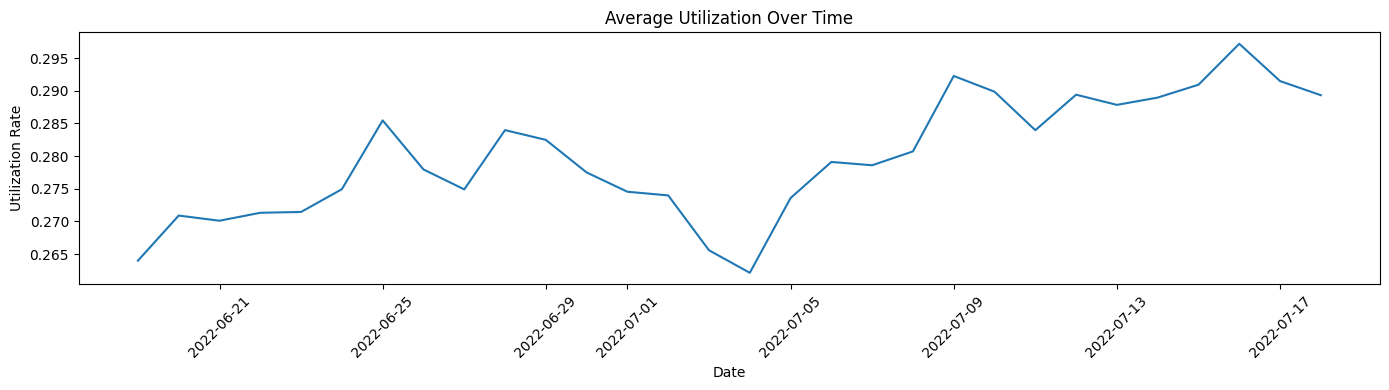

In [23]:
import matplotlib.pyplot as plt

# Average Utilization
plt.figure(figsize=(14,4))
daily_util = panel.groupby(panel["timestamp"].dt.date)["utilization_rate"].mean()
plt.plot(daily_util.index, daily_util.values)
plt.title("Average Utilization Over Time")
plt.xlabel("Date")
plt.ylabel("Utilization Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

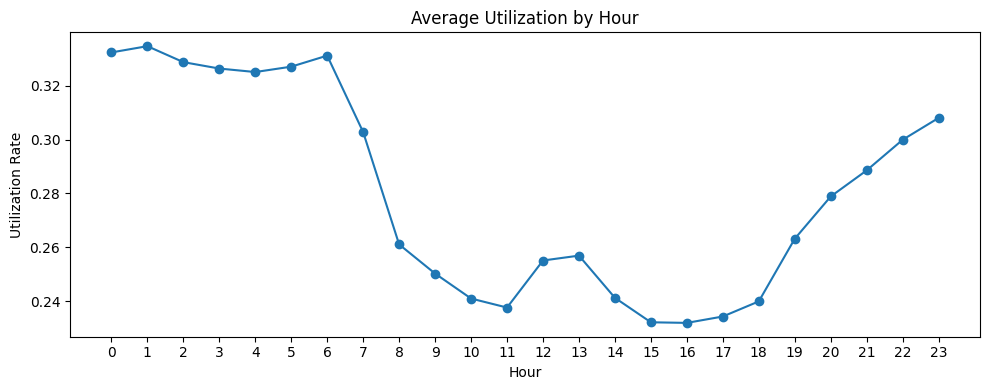

In [24]:
# Average Utilization by Hour
plt.figure(figsize=(10,4))
hourly_util = panel.groupby("hour")["utilization_rate"].mean()
plt.plot(hourly_util.index, hourly_util.values, marker="o")
plt.title("Average Utilization by Hour")
plt.xlabel("Hour")
plt.ylabel("Utilization Rate")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


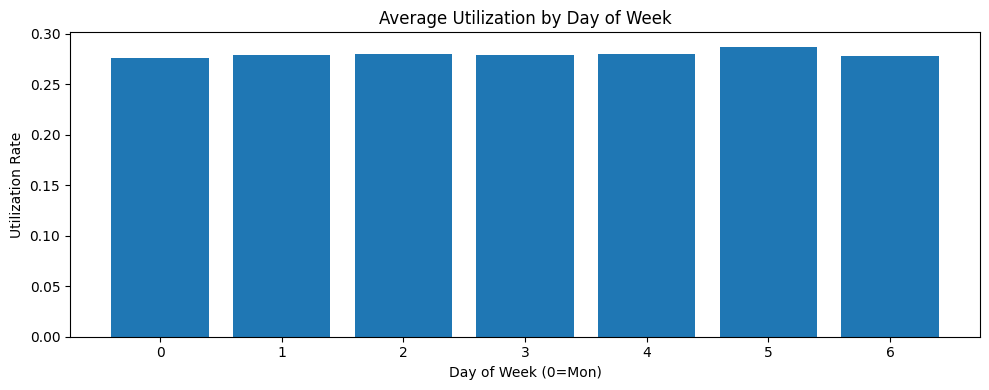

In [25]:
# Average Utilization by Day of Week
plt.figure(figsize=(10,4))
dow_util = panel.groupby("dayofweek")["utilization_rate"].mean()
plt.bar(dow_util.index, dow_util.values)
plt.title("Average Utilization by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Utilization Rate")
plt.tight_layout()
plt.show()

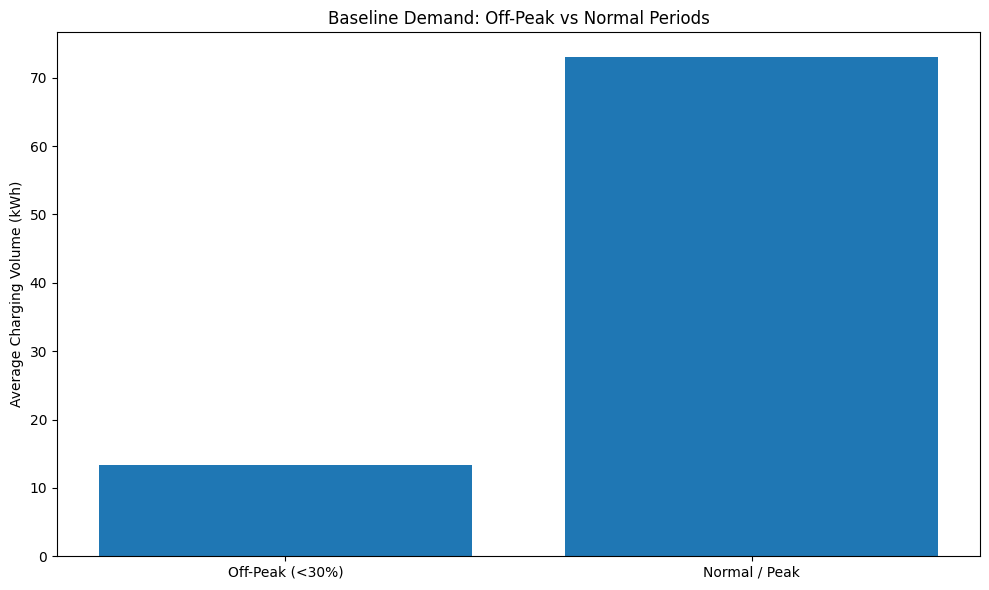

In [48]:
# Baseline Demand: Off-Peak vs Normal Periods.

plt.figure(figsize=(10,6))

offpeak = panel[panel["utilization_rate"] < 0.30]
normal = panel[panel["utilization_rate"] >= 0.30]

data = [offpeak["volume"].mean(), normal["volume"].mean()]

labels = ["Off-Peak (<30%)", "Normal / Peak"]

bars = plt.bar(labels, data)

plt.title("Baseline Demand: Off-Peak vs Normal Periods")
plt.ylabel("Average Charging Volume (kWh)")
plt.tight_layout()

plt.show()

In [49]:
# Train / Val / Test split by time

feature_cols = ["grid","count","fast_count","slow_count","area","lat","lon","CBD","dynamic_pricing","hour",
                "dayofweek","month","is_weekend","hour_sin","hour_cos","dow_sin","dow_cos","occupancy","duration",
                "volume","price","revenue_proxy","energy_cost_per_kwh","queue_length_proxy","occupancy_density",
                "neighbor_occupancy","neighbor_volume","neighbor_price","occupancy_lag_1","occupancy_lag_12",
                "occupancy_lag_36","occupancy_lag_72","volume_lag_1","volume_lag_12","volume_lag_36","volume_lag_72",
                "price_lag_1","price_lag_12","price_lag_36","price_lag_72","utilization_rate_lag_1","utilization_rate_lag_12",
                "utilization_rate_lag_36","utilization_rate_lag_72","neighbor_occupancy_lag_1","neighbor_occupancy_lag_12",
                "neighbor_occupancy_lag_36","neighbor_occupancy_lag_72","occupancy_roll_mean_12","occupancy_roll_std_12",
                "volume_roll_mean_12","volume_roll_std_12","utilization_rate_roll_mean_12","utilization_rate_roll_std_12",]

feature_cols = [c for c in feature_cols if c in panel.columns]

panel[feature_cols] = panel[feature_cols].replace([np.inf, -np.inf], np.nan)
panel = panel.dropna(subset=feature_cols + ["target_util_next", "target_volume_next", "target_congestion_next"]).reset_index(drop=True)

times = np.sort(panel["time_idx"].unique())
t1 = int(len(times) * 0.70)
t2 = int(len(times) * 0.85)

train_times = set(times[:t1])
val_times = set(times[t1:t2])
test_times = set(times[t2:])

train = panel[panel["time_idx"].isin(train_times)].copy()
val = panel[panel["time_idx"].isin(val_times)].copy()
test = panel[panel["time_idx"].isin(test_times)].copy()

X_train = train[feature_cols]
y_train_util = train["target_util_next"]
y_train_vol = train["target_volume_next"]
y_train_cong = train["target_congestion_next"]

X_val = val[feature_cols]
y_val_util = val["target_util_next"]
y_val_vol = val["target_volume_next"]
y_val_cong = val["target_congestion_next"]

X_test = test[feature_cols]
y_test_util = test["target_util_next"]
y_test_vol = test["target_volume_next"]
y_test_cong = test["target_congestion_next"]

In [27]:
print(X_train.shape, X_val.shape, X_test.shape)

(1481012, 54) (317395, 54) (317642, 54)


**Demand Prediction Agent**

In [28]:
# Utilization
util_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, min_child_weight=3, subsample=0.8,
                          colsample_bytree=0.8, reg_alpha=0.2, reg_lambda=1.0, objective="reg:squarederror",
                          tree_method="hist", random_state=42)

util_model.fit(X_train, y_train_util, eval_set=[(X_val, y_val_util)], verbose=100)

pred_util = util_model.predict(X_test)

r2_util = r2_score(y_test_util, pred_util)
mae_util = mean_absolute_error(y_test_util, pred_util)
rmse_util = np.sqrt(mean_squared_error(y_test_util, pred_util))

[0]	validation_0-rmse:0.16670
[100]	validation_0-rmse:0.02018
[200]	validation_0-rmse:0.01781
[299]	validation_0-rmse:0.01668


**Utilization Forecast**

In [29]:
print("R2  :", round(r2_util, 4))
print("MAE :", round(mae_util, 4))
print("RMSE:", round(rmse_util, 4))

R2  : 0.992
MAE : 0.0071
RMSE: 0.0158


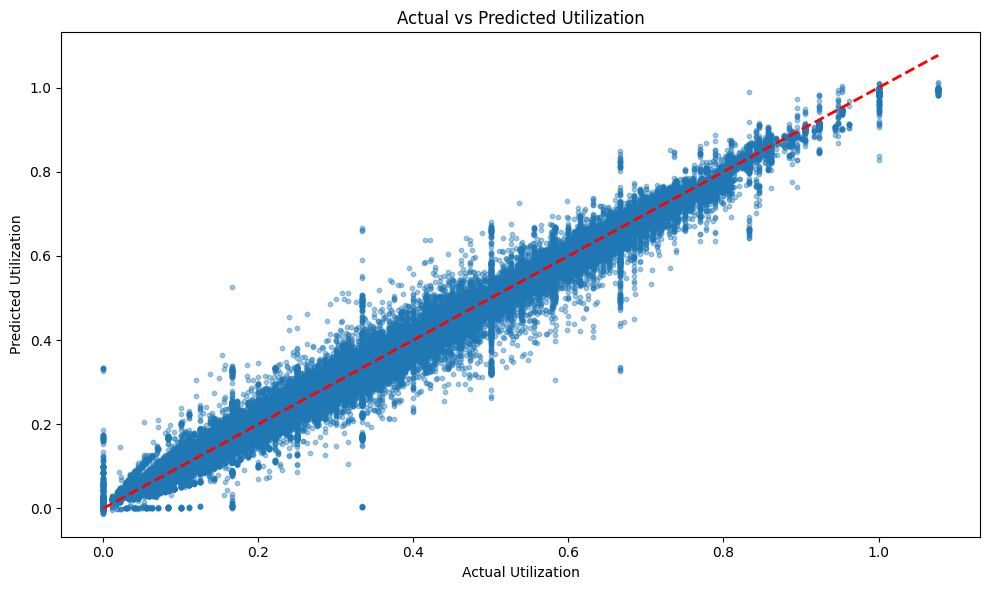

In [50]:
plt.figure(figsize=(10,6))

plt.scatter(y_test_util, pred_util, alpha=0.4, s=10)

plt.plot([y_test_util.min(), y_test_util.max()], [y_test_util.min(), y_test_util.max()], 'r--', linewidth=2)

plt.xlabel("Actual Utilization")
plt.ylabel("Predicted Utilization")
plt.title("Actual vs Predicted Utilization")

plt.tight_layout()
plt.show()

In [30]:
# Charging load (Volume) prediction
load_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, min_child_weight=3, subsample=0.8,
                          colsample_bytree=0.8, reg_alpha=0.2, reg_lambda=1.0, objective="reg:squarederror",
                          tree_method="hist", random_state=42)

load_model.fit(X_train, y_train_vol, eval_set=[(X_val, y_val_vol)], verbose=100)

pred_load = load_model.predict(X_test)

r2_load = r2_score(y_test_vol, pred_load)
mae_load = mean_absolute_error(y_test_vol, pred_load)
rmse_load = mean_squared_error(y_test_vol, pred_load)

[0]	validation_0-rmse:101.83831
[100]	validation_0-rmse:7.03675
[200]	validation_0-rmse:6.60499
[299]	validation_0-rmse:6.46365


**Charging Load Forecast**

In [31]:
print("R2  :", round(r2_load, 4))
print("MAE :", round(mae_load, 4))
print("RMSE:", round(rmse_load, 4))

R2  : 0.9962
MAE : 1.6922
RMSE: 42.6675


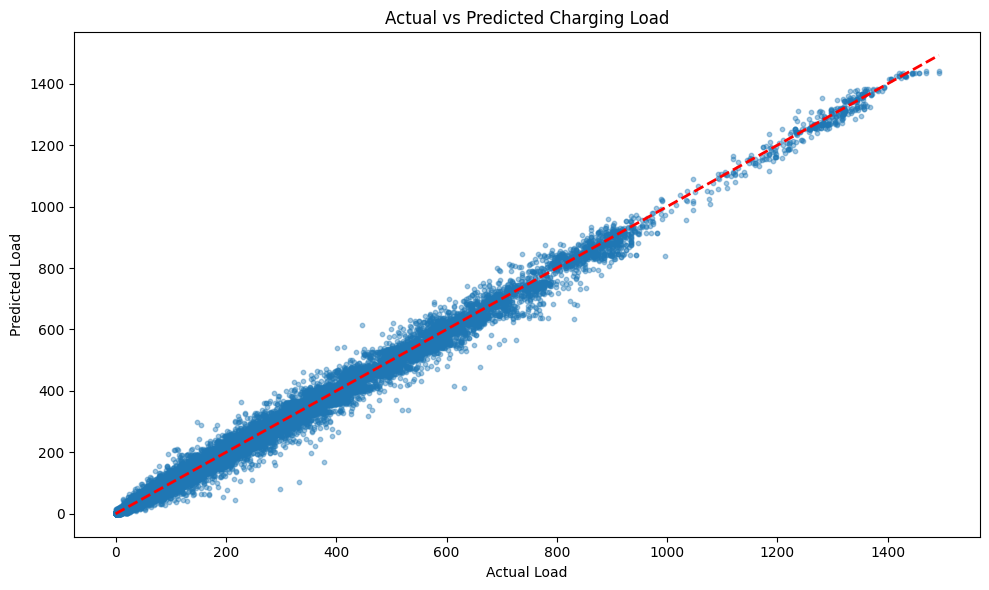

In [52]:
plt.figure(figsize=(10,6))

plt.scatter(y_test_vol, pred_load, alpha=0.4, s=10)

plt.plot([y_test_vol.min(), y_test_vol.max()], [y_test_vol.min(), y_test_vol.max()], 'r--', linewidth=2)

plt.xlabel("Actual Load")
plt.ylabel("Predicted Load")
plt.title("Actual vs Predicted Charging Load")

plt.tight_layout()
plt.show()

In [32]:
# Congestion probability
pos = max(1, int(y_train_cong.sum()))
neg = max(1, int((1 - y_train_cong).sum()))
scale_pos_weight = neg / pos

cong_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, min_child_weight=3, subsample=0.8,
                           colsample_bytree=0.8, reg_alpha=0.2, reg_lambda=1.0, objective="binary:logistic",
                           tree_method="hist", scale_pos_weight=scale_pos_weight, random_state=42)

cong_model.fit(X_train, y_train_cong, eval_set=[(X_val, y_val_cong)], verbose=100)

pred_cong_prob = cong_model.predict_proba(X_test)[:, 1]
pred_cong = (pred_cong_prob >= 0.5).astype(int)

acc_cong = accuracy_score(y_test_cong, pred_cong)
auc_cong = roc_auc_score(y_test_cong, pred_cong_prob)

[0]	validation_0-logloss:0.64531
[100]	validation_0-logloss:0.01707
[200]	validation_0-logloss:0.01248
[299]	validation_0-logloss:0.01022


**Congestion Model**

In [33]:
print("Accuracy:", round(acc_cong, 4))
print("ROC-AUC :", round(auc_cong, 4))

Accuracy: 0.9962
ROC-AUC : 0.9998


**Tariff Pricing Agent**

In [34]:
BASE_TARIFF = 15.0
SURGE_MULT = 1.20
DISC_MULT  = 0.85

def recommend_tariff(pred_util, base=BASE_TARIFF):
    if pred_util >= 0.80:
        return base * SURGE_MULT, "surge"
    elif pred_util < 0.30:
        return base * DISC_MULT, "discount"
    else:
        return base, "normal"

test = test.copy()
test["pred_util_next"] = pred_util
test["pred_congestion_prob"] = pred_cong_prob
test["recommended_tariff"] = test["pred_util_next"].apply(lambda x: recommend_tariff(x)[0])
test["pricing_action"] = test["pred_util_next"].apply(lambda x: recommend_tariff(x)[1])

In [35]:
test[["timestamp","grid","pred_util_next","pred_congestion_prob","recommended_tariff","pricing_action"]].head(10)

,timestamp,grid,pred_util_next,pred_congestion_prob,recommended_tariff,pricing_action
7281,2022-07-14 12:45:00,102,0.503676,0.000010,15.0,normal
7282,2022-07-14 12:50:00,102,0.503028,0.000007,15.0,normal
7283,2022-07-14 12:55:00,102,0.503338,0.000007,15.0,normal
7284,2022-07-14 13:00:00,102,0.502454,0.000009,15.0,normal
7285,2022-07-14 13:05:00,102,0.501818,0.000012,15.0,normal
7286,2022-07-14 13:10:00,102,0.501818,0.000011,15.0,normal
7287,2022-07-14 13:15:00,102,0.501818,0.000013,15.0,normal
7288,2022-07-14 13:20:00,102,0.501818,0.000013,15.0,normal
7289,2022-07-14 13:25:00,102,0.490952,0.000010,15.0,normal
7290,2022-07-14 13:30:00,102,0.468555,0.000010,15.0,normal


In [36]:
BASE_TARIFF = 15.0
ACTIONS = np.array([0.85, 1.00, 1.20])
EPSILON = 0.15
ELASTICITY = -0.5

ALPHA_QUEUE = 200
BETA_CONG = 500
GAMMA_OFFPEAK = 100

df = test.copy().sort_values(["time_idx", "grid"]).reset_index(drop=True)

action_values = {a: 0.0 for a in ACTIONS}
action_counts = {a: 0 for a in ACTIONS}
logs = []

def choose_action():
    if np.random.rand() < EPSILON:
        return np.random.choice(ACTIONS)
    return max(action_values, key=action_values.get)

for t, grp in df.groupby("time_idx"):
    base_volume = grp["volume"].sum()
    base_util = grp["target_util_next"].mean()
    base_queue = np.maximum(grp["target_util_next"] - 0.80, 0).mean()
    base_revenue = base_volume * BASE_TARIFF

    action = choose_action()
    tariff = BASE_TARIFF * action

    demand_multiplier = np.clip(1 + ELASTICITY * (action - 1), 0.60, 1.40)
    sim_volume = base_volume * demand_multiplier
    sim_util = np.clip(base_util * demand_multiplier, 0, 1.5)

    sim_revenue = sim_volume * tariff
    sim_queue = np.maximum(sim_util - 0.80, 0)

    offpeak_before = 1 if base_util < 0.30 else 0
    offpeak_after = 1 if sim_util < 0.30 else 0

    reward = (sim_revenue - ALPHA_QUEUE * sim_queue - BETA_CONG * int(sim_util >= 0.80) + GAMMA_OFFPEAK * offpeak_after)

    action_counts[action] += 1
    action_values[action] += (reward - action_values[action]) / action_counts[action]

    logs.append({
        "time_idx": t,
        "base_volume": base_volume,
        "base_util": base_util,
        "base_queue": base_queue,
        "action_multiplier": action,
        "tariff": tariff,
        "demand_multiplier": demand_multiplier,
        "sim_volume": sim_volume,
        "sim_util": sim_util,
        "sim_queue": sim_queue,
        "base_revenue": base_revenue,
        "sim_revenue": sim_revenue,
        "revenue_gain_pct": ((sim_revenue - base_revenue) / max(base_revenue, 1e-9)) * 100,
        "waiting_time_reduction": base_queue - sim_queue,
        "customer_response_rate": ((sim_volume - base_volume) / max(base_volume, 1e-9)) * 100,
        "pricing_efficiency_before": base_revenue / max(base_volume, 1e-9),
        "pricing_efficiency_after": sim_revenue / max(sim_volume, 1e-9),
        "offpeak_before": offpeak_before,
        "offpeak_after": offpeak_after,
        "reward": reward
    })

log_df = pd.DataFrame(logs)

baseline_revenue = log_df["base_revenue"].sum()
dynamic_revenue = log_df["sim_revenue"].sum()

revenue_gain_pct = ((dynamic_revenue - baseline_revenue) / max(baseline_revenue, 1e-9)) * 100

util_before = log_df["base_util"].mean()
util_after = log_df["sim_util"].mean()

offpeak_sessions_before = log_df.loc[log_df["base_util"] < 0.30, "base_volume"].sum()
offpeak_sessions_after = log_df.loc[log_df["sim_util"] < 0.30, "sim_volume"].sum()
offpeak_uplift_pct = ((offpeak_sessions_after - offpeak_sessions_before) / max(offpeak_sessions_before, 1e-9)) * 100

avg_wait_before = log_df["base_queue"].mean()
avg_wait_after = log_df["sim_queue"].mean()
avg_wait_reduction = avg_wait_before - avg_wait_after

customer_response_rate = log_df["customer_response_rate"].mean()

pricing_eff_before = log_df["pricing_efficiency_before"].mean()
pricing_eff_after = log_df["pricing_efficiency_after"].mean()

**MONITORING & LEARNING AGENT RESULTS**

In [37]:
print("Baseline Revenue         :", round(baseline_revenue, 2))
print("Dynamic Revenue          :", round(dynamic_revenue, 2))
print("Revenue Gain %           :", round(revenue_gain_pct, 2))
print("Charger Utilization Before:", round(util_before, 4))
print("Charger Utilization After :", round(util_after, 4))
print("Off-Peak Uplift %        :", round(offpeak_uplift_pct, 2))
print("Avg Waiting Time Before  :", round(avg_wait_before, 4))
print("Avg Waiting Time After   :", round(avg_wait_after, 4))
print("Avg Waiting Time Reduction:", round(avg_wait_reduction, 4))
print("Customer Response Rate % :", round(customer_response_rate, 2))
print("Pricing Efficiency Before :", round(pricing_eff_before, 4))
print("Pricing Efficiency After  :", round(pricing_eff_after, 4))

print("\nLEARNED ACTION VALUES")
for a in ACTIONS:
    print(f"Multiplier {a}: value={action_values[a]:.4f}, count={action_counts[a]}")

Baseline Revenue         : 192174158.95
Dynamic Revenue          : 205139111.07
Revenue Gain %           : 6.75
Charger Utilization Before: 0.2898
Charger Utilization After : 0.2647
Off-Peak Uplift %        : 27.82
Avg Waiting Time Before  : 0.0008
Avg Waiting Time After   : 0.0
Avg Waiting Time Reduction: 0.0008
Customer Response Rate % : -8.63
Pricing Efficiency Before : 15.0
Pricing Efficiency After  : 17.5894

LEARNED ACTION VALUES
Multiplier 0.85: value=142675.3189, count=64
Multiplier 1.0: value=146191.6685, count=64
Multiplier 1.2: value=161269.5370, count=1158


In [38]:
log_df.to_csv("monitoring_learning_log.csv", index=False)

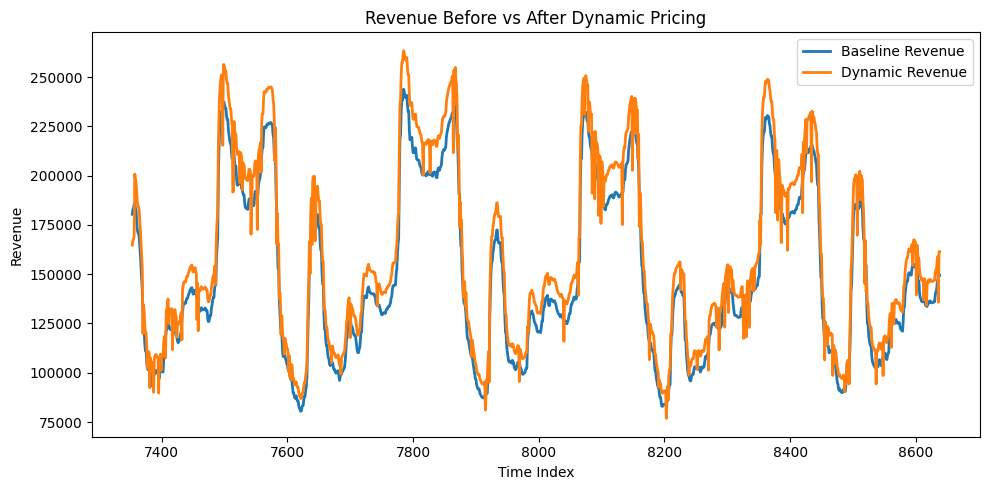

In [39]:
plt.style.use("default")

# Revenue before vs after
plt.figure(figsize=(10,5))
plt.plot(log_df["time_idx"], log_df["base_revenue"], label="Baseline Revenue", linewidth=2)
plt.plot(log_df["time_idx"], log_df["sim_revenue"], label="Dynamic Revenue", linewidth=2)
plt.title("Revenue Before vs After Dynamic Pricing")
plt.xlabel("Time Index")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

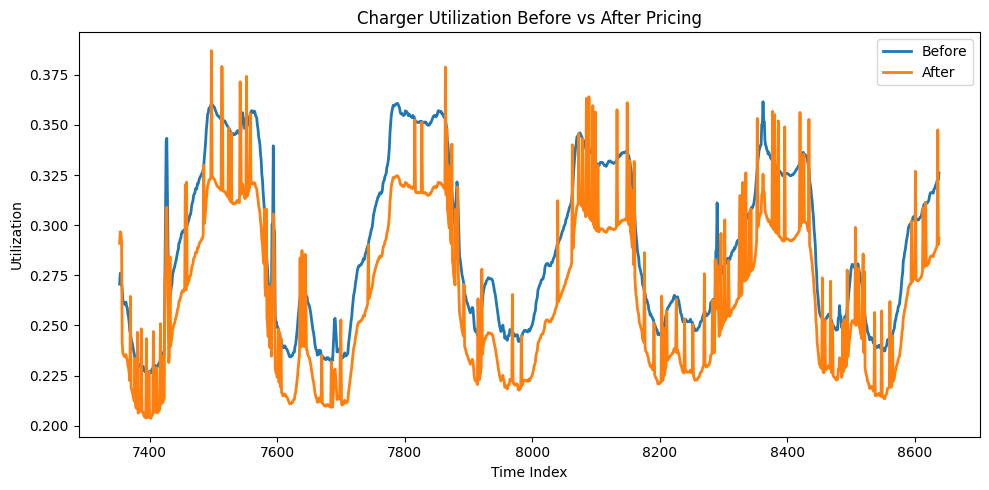

In [40]:
# Utilization before vs after
plt.figure(figsize=(10,5))
plt.plot(log_df["time_idx"], log_df["base_util"], label="Before", linewidth=2)
plt.plot(log_df["time_idx"], log_df["sim_util"], label="After", linewidth=2)
plt.title("Charger Utilization Before vs After Pricing")
plt.xlabel("Time Index")
plt.ylabel("Utilization")
plt.legend()
plt.tight_layout()
plt.show()

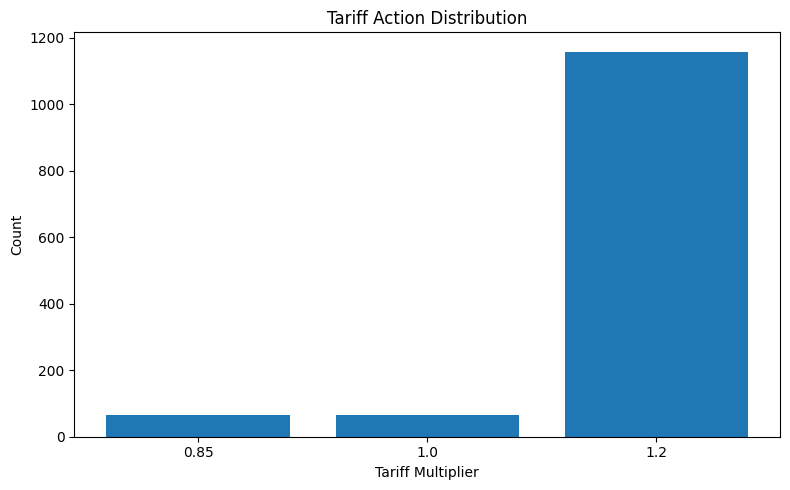

In [41]:
# Tariff action distribution
plt.figure(figsize=(8,5))
actions = log_df["action_multiplier"].value_counts().sort_index()
plt.bar(actions.index.astype(str), actions.values)
plt.title("Tariff Action Distribution")
plt.xlabel("Tariff Multiplier")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

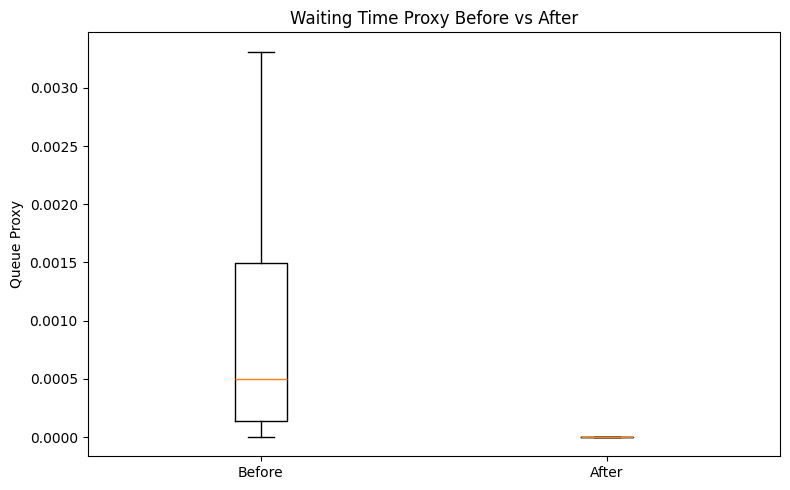

In [42]:
# Waiting time proxy before vs after
plt.figure(figsize=(8,5))
plt.boxplot([log_df["base_queue"], log_df["sim_queue"]], tick_labels=["Before", "After"])
plt.title("Waiting Time Proxy Before vs After")
plt.ylabel("Queue Proxy")
plt.tight_layout()
plt.show()

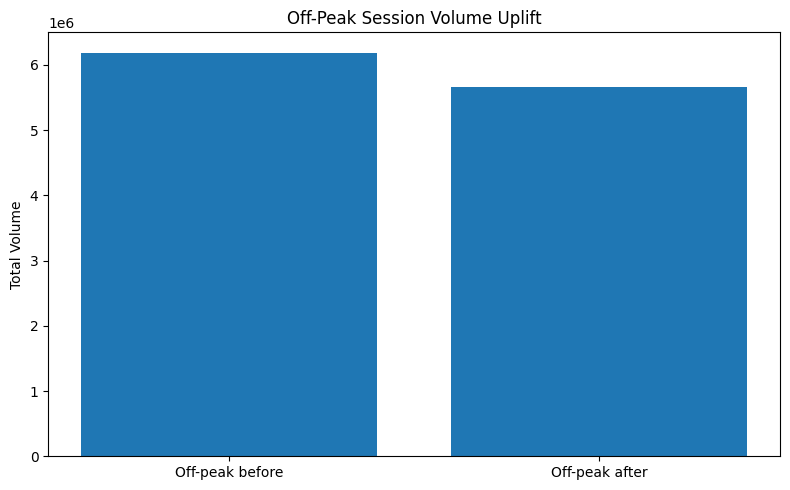

In [43]:
# Off-peak vs peak utilization pattern
peak_mask = log_df["base_util"] >= 0.80
offpeak_mask = log_df["base_util"] < 0.30

plt.figure(figsize=(8,5))
plt.bar(["Off-peak before", "Off-peak after"],
        [log_df.loc[offpeak_mask, "base_volume"].sum(), log_df.loc[offpeak_mask, "sim_volume"].sum()])
plt.title("Off-Peak Session Volume Uplift")
plt.ylabel("Total Volume")
plt.tight_layout()
plt.show()

**Final Table**

In [44]:
final_output = log_df.copy()

final_output.to_csv("dynamic_tariff_predictions.csv", index=False)

In [45]:
print(final_output.head())

   time_idx   base_volume  base_util  base_queue  action_multiplier  tariff  \
0      7353  12027.836944   0.270616    0.001030               0.85   12.75   
1      7354  12189.881111   0.276018    0.001206               0.85   12.75   
2      7355  12234.416667   0.275566    0.001037               0.85   12.75   
3      7356  12364.500000   0.271686    0.000778               0.85   12.75   
4      7357  12394.238889   0.268131    0.000690               1.20   18.00   

   demand_multiplier    sim_volume  sim_util  sim_queue   base_revenue  \
0              1.075  12929.924715  0.290912        0.0  180417.554164   
1              1.075  13104.122194  0.296719        0.0  182848.216664   
2              1.075  13151.997917  0.296234        0.0  183516.250001   
3              1.075  13291.837500  0.292063        0.0  185467.500002   
4              0.900  11154.815000  0.241318        0.0  185913.583330   

     sim_revenue  revenue_gain_pct  waiting_time_reduction  \
0  164856.540118  